Filter original expression matrix for Mixscape "escaped cells":

Here, we filter the msfiltered anndata object according to the extracted signaling network. We also embed the activity matrix in PCA/UMAP space.

In [1]:
import os
import ast
import json
import time

from tqdm import tqdm
from tqdm import trange

import numpy as np
import pandas as pd

import scanpy as sc
# import umap

import matplotlib.pyplot as plt
import seaborn as sns

import sys
sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io
from scLEMBAS import preprocess as pp
from scLEMBAS import latent_separation as ls


/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/nobackup/


[KeOps] Warning : There were warnings or errors :
<stdin>:1:10: fatal error: cuda.h: No such file or directory
compilation terminated.

[KeOps] Warning : 
    The location of Cuda header files cuda.h and nvrtc.h could not be detected on your system.
    You must determine their location and then define the environment variable CUDA_PATH,
    either before launching Python or using os.environ before importing keops. For example
    if these files are in /vol/cuda/10.2.89-cudnn7.6.4.38/include you can do :
      import os
      os.environ['CUDA_PATH'] = '/vol/cuda/10.2.89-cudnn7.6.4.38'
    
[KeOps] Compiling cuda jit compiler engine ... 


[KeOps] Warning : There were warnings or errors :
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/keopscore/binders/nvrtc/nvrtc_jit.cpp:16:10: fatal error: cuda.h: No such file or directory
 #include <cuda.h>
          ^~~~~~~~
compilation terminated.

OK


[pyKeOps] Compiling nvrtc binder for python ... 


[KeOps] Warning : There were warnings or errors :
In file included from /nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/pykeops/common/keops_io/pykeops_nvrtc.cpp:8:
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/keopscore/binders/nvrtc/keops_nvrtc.cpp:17:10: fatal error: cuda.h: No such file or directory
 #include <cuda.h>
          ^~~~~~~~
compilation terminated.

OK


/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
n_cores = 30
os.environ["OMP_NUM_THREADS"] = str(n_cores)
os.environ["MKL_NUM_THREADS"] = str(n_cores)
os.environ["OPENBLAS_NUM_THREADS"] = str(n_cores)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(n_cores)
os.environ["NUMEXPR_NUM_THREADS"] = str(n_cores)

seed = 888
data_path = '/nobackup/users/hmbaghda/scLEMBAS/analysis'
author = 'Tahoe100M'

In [3]:
adata = sc.read_h5ad(os.path.join(data_path, 'interim', author + '_filtered_counts.h5ad'))

<span style="color:red; font-weight:bold">Delete This:</span>


In [4]:
# rng = np.random.default_rng(seed=888)
# n_frac = 0.01
# idx = rng.choice(adata.n_obs, size=int(adata.n_obs *n_frac), replace=False)
# adata = adata[idx, :]

# Preprocessing:

In [5]:
from scLEMBAS.pertpy_mixscape import Mixscape
from scipy.sparse import csr_matrix, save_npz, load_npz

In [6]:
sc.pp.normalize_total(adata, target_sum = 1e6)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=3000, batch_key=None, flavor = 'seurat')

# generated in msA
adata.layers["X_pert"] = load_npz(os.path.join(data_path, 'interim', author + '_temp_X_pert.npz'))

In [7]:
# rng = np.random.default_rng(seed=888)
# n_frac = 0.01
# idx = rng.choice(adata.n_obs, size=int(adata.n_obs *n_frac), replace=False)
# adata = adata[idx, :]

In [8]:
adata.layers['norm_counts'] = adata.X

ms = Mixscape()
adata = ms.mixscape(
    adata = adata, 
    labels = 'drug', 
    control = 'DMSO_TF', 
    layer = 'X_pert', 
    min_de_genes = 5, # as in Mixscape
    logfc_threshold = 0.25, # pertpy default
    de_layer = None, # wilcoxon expects log-normalized data according to scanpy documentation
    test_method = 'wilcoxon', 
    iter_num = 10, # as in Mixscape
    scale = True, # discrepancy with original Mixscape mentioned in markdown above
    split_by = None, # can try splitting by cell_line eventually
    pval_cutoff = 5e-2, # as in Mixscape
    random_state = seed,
    copy = True, 
    **{
        'verbose': False, 
        
    }
)


In [9]:
obs_ms = adata.obs.copy() # store the categorization
obs_ms.to_csv(os.path.join(data_path, 'processed', author + '_mixscape_classification.csv'))
adata.X = adata.layers['norm_counts'] # was overwritted with X_pert layer in mixscape method

# exclude escaped cells
adata = adata[adata.obs.mixscape_class_global != 'NP'].copy()

Since we have retained only a subset of cells, recalculate the HVGs:

In [10]:
sc.pp.highly_variable_genes(adata, n_top_genes=3000, batch_key=None, flavor = 'seurat')

# Embeddings

In [11]:
covariate_associations = ['cell_line', 'drug', 'plate', 'phase', 'S_score', 'G2M_score', 'pcnt_mito']

## PCA Space

Get the dimensionality reduction on the perturbation signature:

Note a discrepancy here: pertpy scales AND zero-centers the DE-subsetted perturbation signature (in the mixscape method), whereas the original Mixscape only zero-centers the entire matrix without subsetting. We will proceed with the pertpy implementation for simplicity. We run PCA on the HVGs identified from the expression matrix as in the Mixscape paper. 


In [12]:
file_prefix = os.path.join(data_path, 'processed', author + '_msfiltered_activity_pca')

In [13]:
adata, r2_df = ls.pc_pipeline(
    adata = adata,
    pert_ids = adata.obs.drug.unique(), # don't subset
    cat_ids = adata.obs.cell_line.unique(), # don't subset
    n_components = None, # estimate out of 50
    pert_col = 'drug',
    cat_col = 'cell_line',
    get_hvgs = False, 
    run_umap = True,
    covariate_associations = covariate_associations, 
    file_prefix = file_prefix,
    verbose = False,
    n_cores = n_cores,
    seed = 888,
    embkwrgs = {
        'cluster_data': False, 
        'scale': False,
        'pc_projection_tol': 1e-2,# typically 5e-4, but projection values are larger
        'pcakwrgs': {
            'use_highly_variable': True, # identified in log-normalized data
            'zero_center': True
        }    
    }
)


/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/preprocessing/_pca.py:374: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)


/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


cell_line


  0%|                                                                                                | 0/12 [00:00<?, ?it/s]

 17%|██████████████▋                                                                         | 2/12 [00:00<00:00, 19.00it/s]

...

 75%|██████████████████████████████████████████████████████████████████                      | 9/12 [01:21<00:26,  8.73s/it]

 83%|████████████████████████████████████████████████████████████████████████▌              | 10/12 [01:29<00:17,  8.64s/it]

 92%|███████████████████████████████████████████████████████████████████████████████▊       | 11/12 [01:37<00:08,  8.39s/it]

100%|███████████████████████████████████████████████████████████████████████████████████████| 12/12 [01:47<00:00,  9.00s/it]

100%|███████████████████████████████████████████████████████████████████████████████████████| 12/12 [01:47<00:00,  8.99s/it]

Elbow selection:

The elbow was automatically identified at PC 12


''

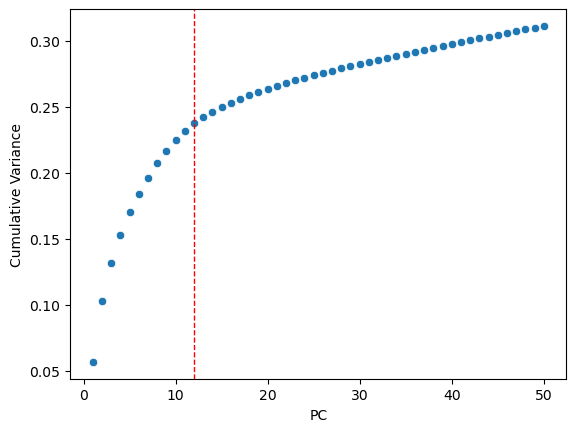

In [14]:
fig, ax = plt.subplots()
sns.scatterplot(
    y=np.cumsum(adata.uns['pca']['variance_ratio']),
    x=range(1, adata.uns['pca']['variance_ratio'].shape[0] + 1),
    ax=ax
)
ax.set_ylabel('Cumulative Variance')
ax.set_xlabel('PC')

n_pcs = adata.uns['pca']['pca_rank']
ax.axvline(x=n_pcs, color='red', linestyle='--', linewidth=1)

print('The elbow was automatically identified at PC {}'.format(n_pcs))
;

The two PC components that best univariately separate by drug are components 1 and 10 explaining 49.74% and 14.65% of variance, respectively
The two PC components that best univariately separate by cell_line are components 3 and 2 explaining 82.07% and 81.55% of variance, respectively


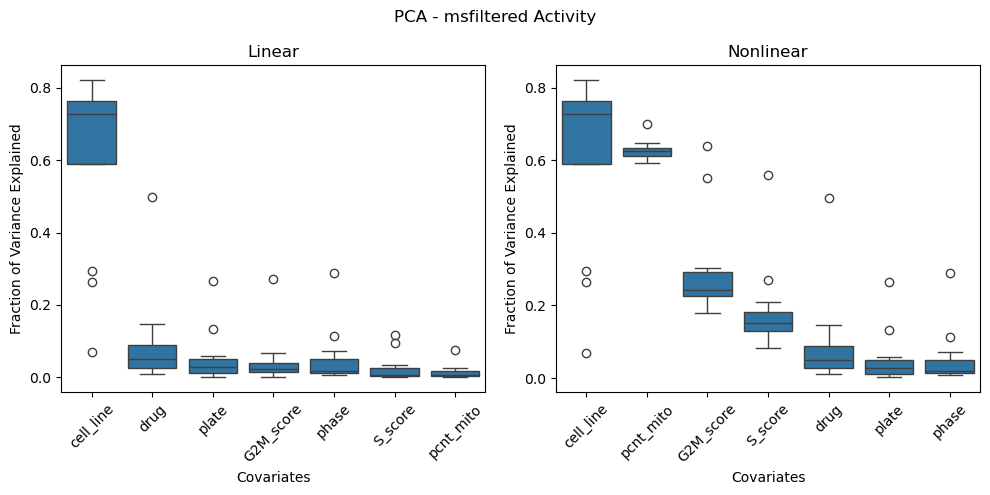

In [15]:
ls.visualize_latent_association(
    r2_df = r2_df, 
    fig_title = 'PCA - msfiltered Activity', 
    file_name = file_prefix + '_associations.png'
)

top_components_drug = ls.get_top_components(r2_df, top_components_cov = 'drug')
top_components_cl = ls.get_top_components(r2_df, top_components_cov = 'cell_line')

In [16]:
pd.melt(
    r2_df.set_index(r2_df.columns[0]), 
    id_vars='model_type', 
    var_name='covariate'
).groupby(['model_type','covariate']).median().sort_values(by = ['model_type', 'value'])


value
model_type covariate          
linear     pcnt_mito  0.005974
           S_score    0.006826
           phase      0.018270
           G2M_score  0.023296
           plate      0.028277
           drug       0.049846
           cell_line  0.726843
nonlinear  phase      0.018270
           plate      0.028277
           drug       0.049844
           S_score    0.152331
           G2M_score  0.241898
           pcnt_mito  0.624586
           cell_line  0.726843

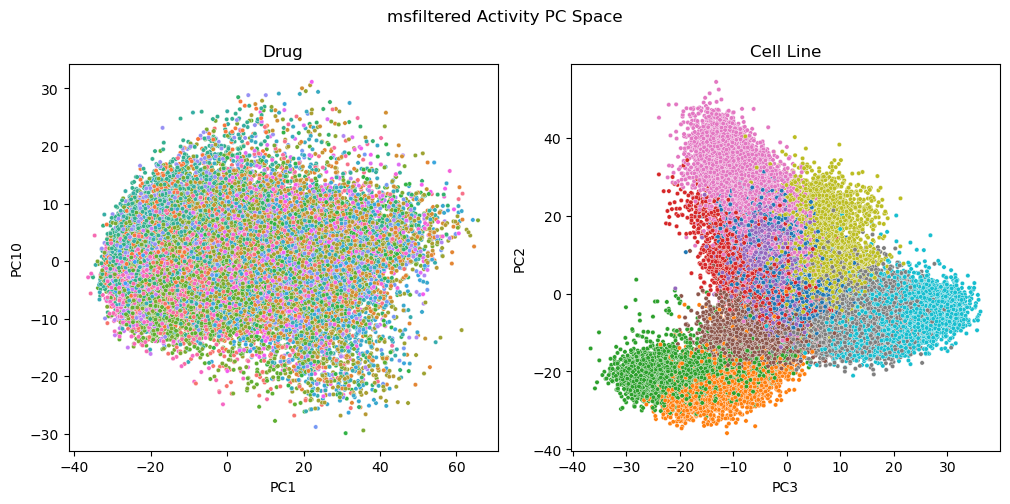

In [17]:
ls.visualize_latent_space(
    adata = adata, 
    latent_label = 'pca', 
    covariates = ['drug', 'cell_line'],
    panel_titles = ['Drug', 'Cell Line'],
    components = {'drug': top_components_drug, 
                  'cell_line': top_components_cl}, 
    n_frac = 0.2, 
    frac_col = None, 
    fig_title = 'msfiltered Activity PC Space', 
    legend = False, 
    seed = 888, 
    file_name = file_prefix + '_space.png'
)

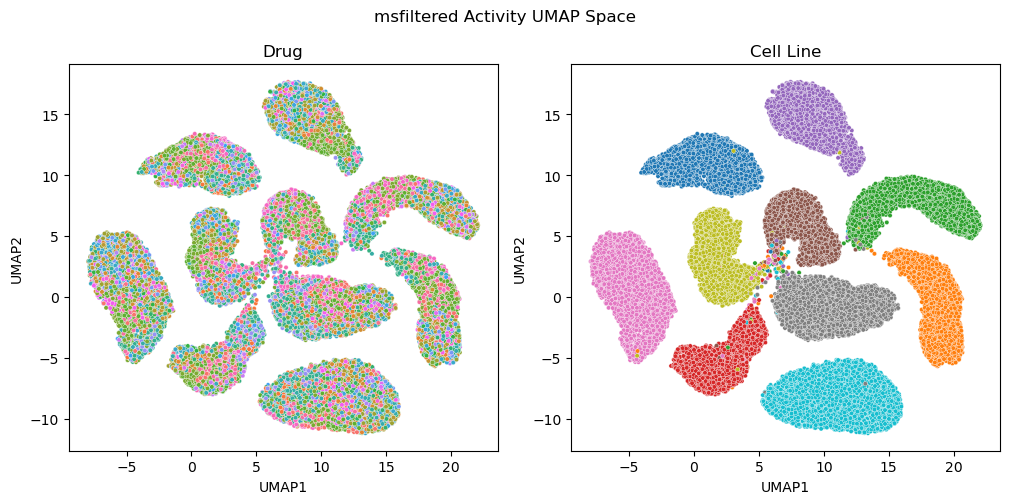

In [18]:
ls.visualize_latent_space(
    adata = adata, 
    latent_label = 'umap', 
    covariates = ['drug', 'cell_line'],
    panel_titles = ['Drug', 'Cell Line'],
    components = [1,2], 
    n_frac = 0.2, 
    frac_col = None, 
    fig_title = 'msfiltered Activity UMAP Space', 
    legend = False, 
    seed = 888, 
    file_name = file_prefix + '_umap_space.png'
)

## PLS-DA 

For PLS-DA:
- again, we do not scale since the input is normalized
- we use our automated elbow analysis to identify the number of covariates
- umap is run categorically on drug
- we filter for HVGs for compute time (and bc this is more comparable with PCA)

In [19]:
file_prefix = os.path.join(data_path, 'processed', author + '_msfiltered_activity_pls')
filter_hvgs_pls = True

In [20]:
if filter_hvgs_pls:
    adata = adata[:, adata.var['highly_variable']]

In [21]:
adata, r2_df = ls.pls_da_pipeline(
    adata = adata, 
    pert_ids = adata.obs.drug.unique(), # don't subset
    cat_ids = adata.obs.cell_line.unique(), # don't subset
    n_components = None, 
    pert_col = 'drug', 
    cat_col = 'cell_line', 
    separate_by = 'perturbation', 
    control_confounders = [], 
    covariate_associations = covariate_associations,
    scale = False, # msfiltered activity already Z-scored
    run_umap = True, 
    file_prefix = file_prefix, 
    verbose = True,
    seed = seed, 
    n_cores = n_cores
)


Run elbow selection


  0%|                                                                                                | 0/25 [00:00<?, ?it/s]

  4%|███▍                                                                                 | 1/25 [03:03<1:13:18, 183.29s/it]

  8%|██████▊                                                                              | 2/25 [06:01<1:09:12, 180.53s/it]

 12%|██████████▏                                                                          | 3/25 [08:51<1:04:22, 175.56s/it]

...

 90%|███████████████████████████████████████████████████████████████████████████████▏        | 9/10 [01:25<00:09,  9.22s/it]

100%|███████████████████████████████████████████████████████████████████████████████████████| 10/10 [01:34<00:00,  9.21s/it]

100%|███████████████████████████████████████████████████████████████████████████████████████| 10/10 [01:34<00:00,  9.42s/it]


/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


Get UMAP


In [22]:
adata.uns['pls']['model_fit']

{'n_components': 10,
 'accuracy': 0.33157030223390277,
 'explained_y': 0.11246801680186691}

''

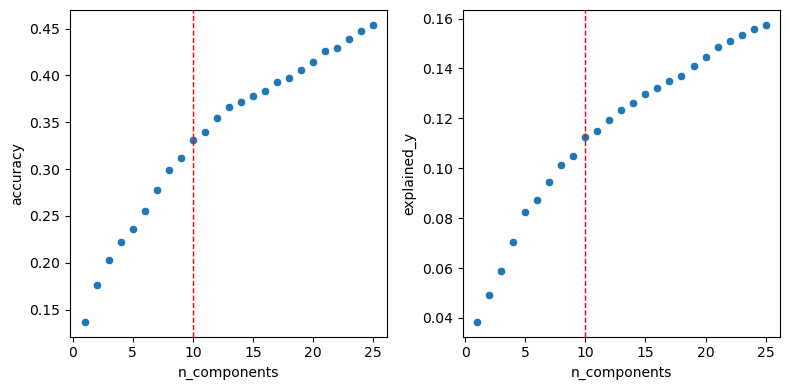

In [23]:
elbow_df = adata.uns['pls']['elbow_analysis']

n_components = adata.uns['pls']['model_fit']['n_components']
fig, ax = plt.subplots(ncols = 2, figsize = (8, 4))
for (i, metric) in enumerate(['accuracy', 'explained_y']):
    sns.scatterplot(data = elbow_df, x = 'n_components', y = metric, ax = ax[i])
    ax[i].axvline(x=n_components, color='red', linestyle='--', linewidth=1)
   
    
fig.tight_layout()
;

The two PLS components that best univariately separate by drug are components 1 and 2 explaining 63.04% and 24.93% of variance, respectively
The two PLS components that best univariately separate by cell_line are components 9 and 2 explaining 63.51% and 58.29% of variance, respectively


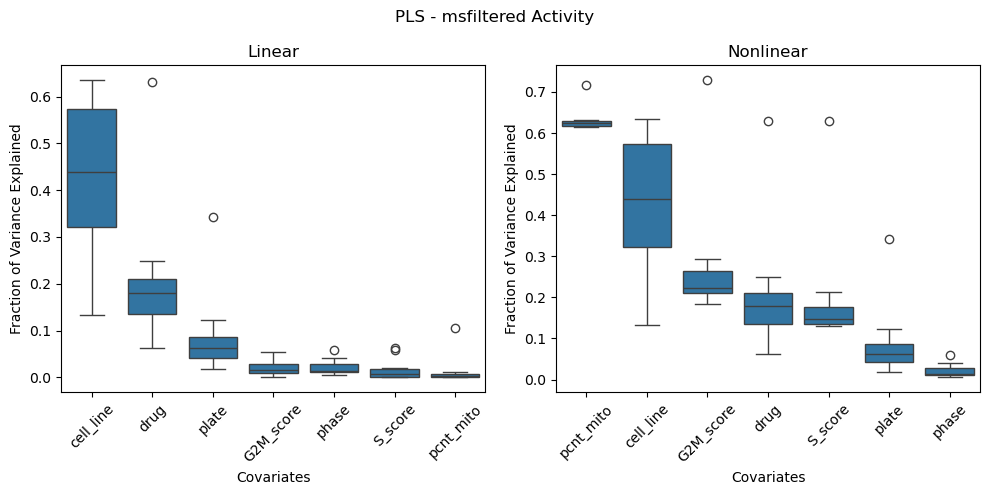

In [24]:
top_components = ls.visualize_latent_association(
    r2_df = r2_df, 
    fig_title = 'PLS - msfiltered Activity', 
    file_name = file_prefix + '_associations.png'
)

top_components_drug = ls.get_top_components(r2_df, top_components_cov = 'drug')
top_components_cl = ls.get_top_components(r2_df, top_components_cov = 'cell_line')

In [25]:
pd.melt(
    r2_df.set_index(r2_df.columns[0]), 
    id_vars='model_type', 
    var_name='covariate'
).groupby(['model_type','covariate']).median().sort_values(by = ['model_type', 'value'])


value
model_type covariate          
linear     pcnt_mito  0.002875
           S_score    0.006621
           phase      0.014438
           G2M_score  0.014673
           plate      0.062543
           drug       0.179398
           cell_line  0.438301
nonlinear  phase      0.014438
           plate      0.062543
           S_score    0.148288
           drug       0.179396
           G2M_score  0.222272
           cell_line  0.438301
           pcnt_mito  0.624006

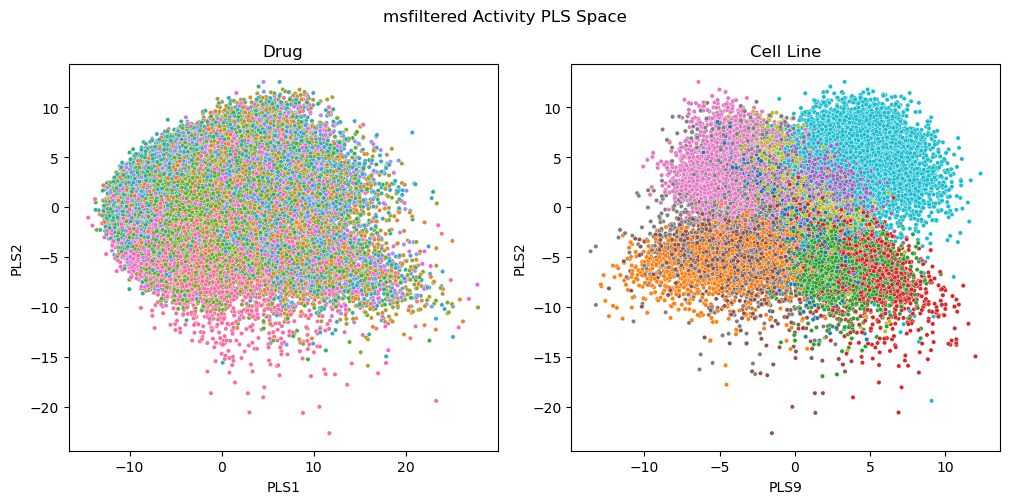

In [26]:
ls.visualize_latent_space(
    adata = adata, 
    latent_label = 'pls', 
    covariates = ['drug', 'cell_line'], 
    panel_titles = ['Drug', 'Cell Line'],
    components = {'drug': top_components_drug, 
                  'cell_line': top_components_cl}, 
    n_frac = 0.2, 
    frac_col = None, 
    fig_title = 'msfiltered Activity PLS Space', 
    legend = False, 
    seed = 888, 
    file_name = file_prefix + '_space.png'
)

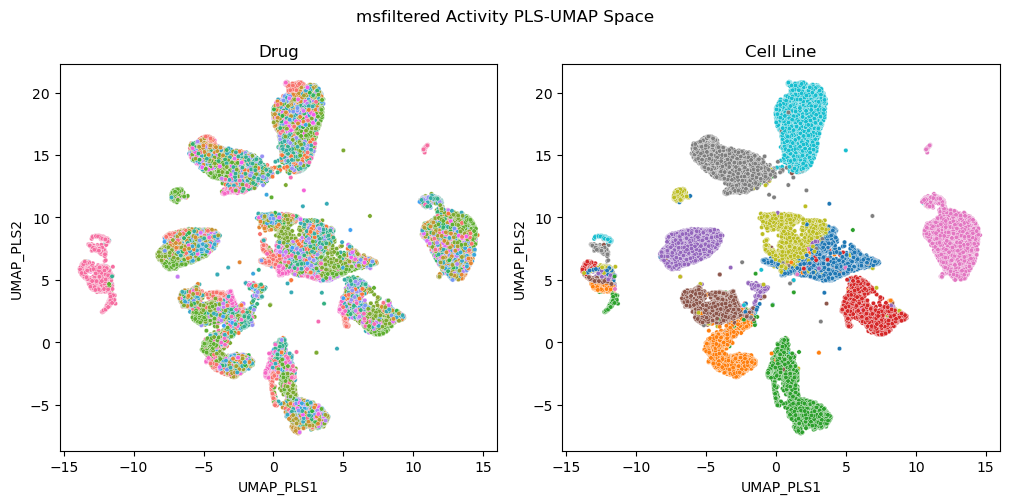

In [27]:
ls.visualize_latent_space(
    adata = adata, 
    latent_label = 'umap_pls', 
    covariates = ['drug', 'cell_line'], 
    panel_titles = ['Drug', 'Cell Line'],
    components = [1,2], 
    n_frac = 0.2, 
    frac_col = None, 
    fig_title = 'msfiltered Activity PLS-UMAP Space', 
    legend = False, 
    seed = 888, 
    file_name = file_prefix + '_umap_space.png'
)